In [21]:
!pip install pandas numpy matplotlib seaborn

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [23]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

In [24]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [26]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [27]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop('Cabin', axis=1, inplace=True)

In [28]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [29]:
df['FamilySize'] = df['SibSp'] + df['Parch']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,19,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

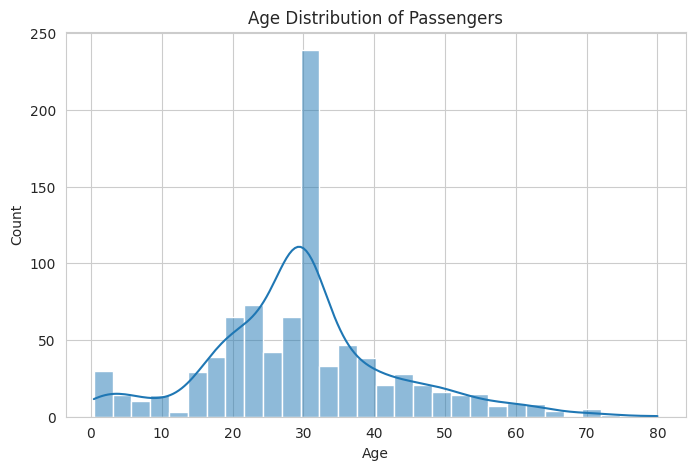

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution of Passengers")

plt.show()

### Insight

Most passengers were between 20 and 40 years old. The age distribution is concentrated among young adults.


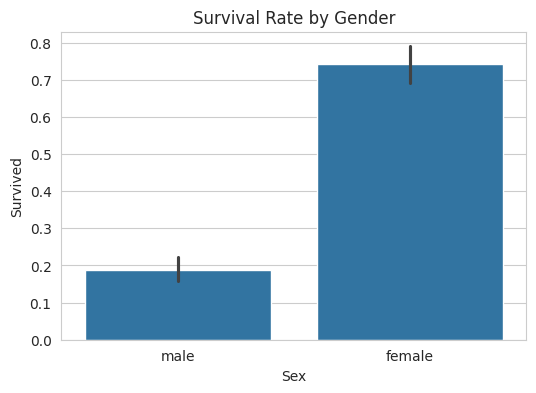

In [31]:
plt.figure(figsize=(6,4))

sns.barplot(x='Sex', y='Survived', data=df)

plt.title("Survival Rate by Gender")

plt.show()

### Insight

Female passengers had significantly higher survival rates than male passengers.

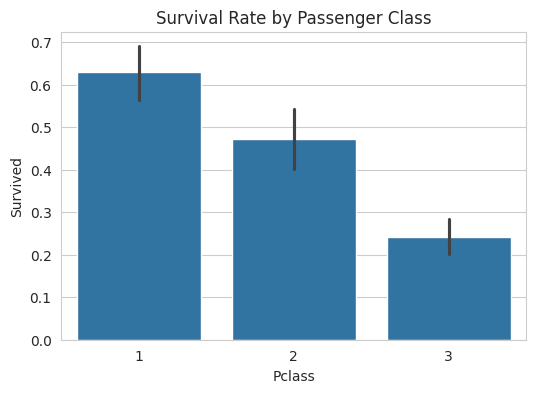

In [32]:
plt.figure(figsize=(6,4))

sns.barplot(x='Pclass', y='Survived', data=df)

plt.title("Survival Rate by Passenger Class")

plt.show()

### Insight

Passengers traveling in First Class had the highest survival rates compared to Second and Third Class passengers.

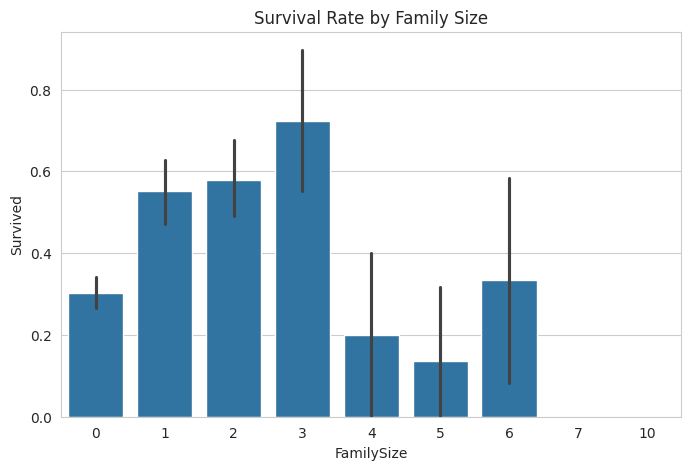

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(x='FamilySize', y='Survived', data=df)

plt.title("Survival Rate by Family Size")

plt.show()

### Insight

Passengers traveling with small to medium-sized families generally had better survival rates.

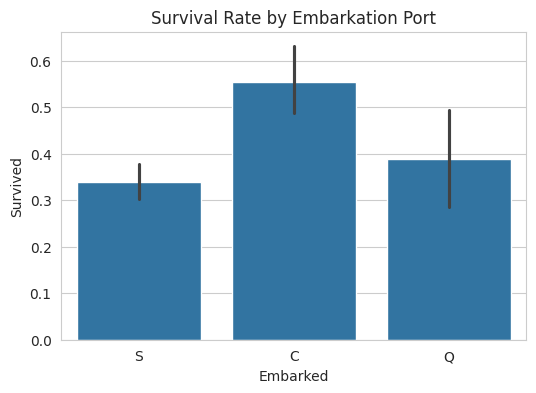

In [34]:
plt.figure(figsize=(6,4))

sns.barplot(x='Embarked', y='Survived', data=df)

plt.title("Survival Rate by Embarkation Port")

plt.show()

### Insight

Survival rates varied across embarkation ports, indicating location-based differences.

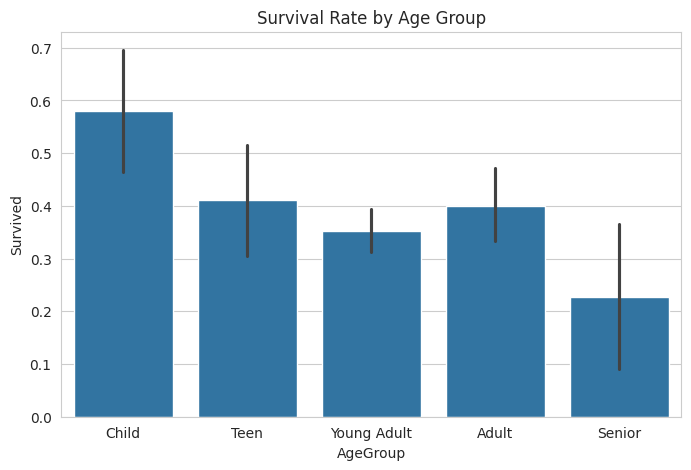

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(x='AgeGroup', y='Survived', data=df)

plt.title("Survival Rate by Age Group")

plt.show()

### Insight

Children and younger passengers generally showed higher survival rates.

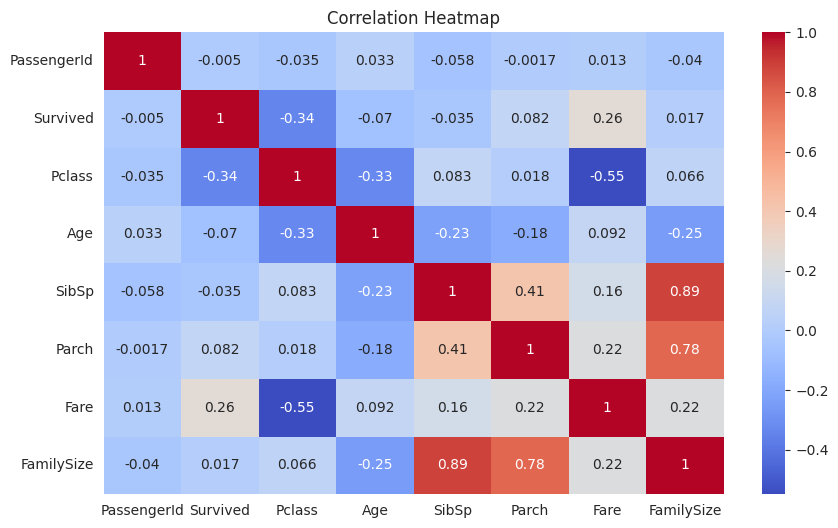

In [36]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The heatmap highlights relationships among numerical variables such as Age, Fare, Family Size, and Survival.

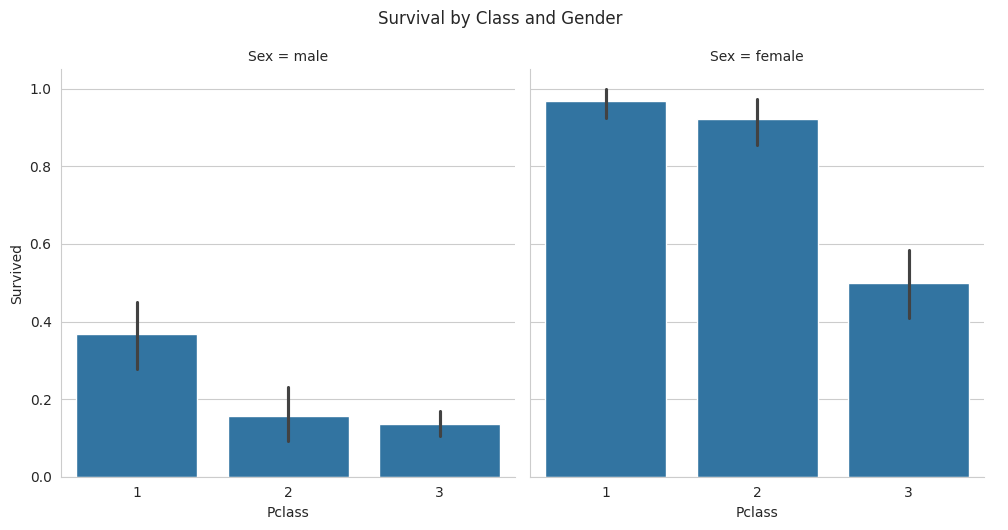

In [37]:
g = sns.catplot(
    col="Sex",
    x="Pclass",
    y="Survived",
    kind="bar",
    data=df
)

g.fig.suptitle("Survival by Class and Gender", y=1.05)

plt.show()

### Insight

Across all passenger classes, female passengers consistently had higher survival rates than males.

In [38]:
df.to_csv('cleaned_titanic_task4.csv', index=False)

Final Conclusion

1. Female passengers had higher survival rates than males.
2. First-class passengers had the best survival chances.
3. Children and young adults survived more frequently.
4. Family size influenced survival outcomes.
5. Embarkation port showed differences in survival rates.
6. Data visualization helped uncover meaningful survival patterns.